<a href="https://colab.research.google.com/github/rajannnnnnn/PowerBi-UNIVERSITY_EXAM_PERFORMANCE_ANALYSIS/blob/Final-raw-to-Complete/ml_captsron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title : credit card fraud detection

## 1) Exploratory Data Analysis (EDA):

## step1 : Dataloading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report

In [ ]:
path = 'https://raw.githubusercontent.com/ArchanaInsights/Datasets/refs/heads/main/credit_card_transactions.csv'
df=pd.read_csv(path)
df



,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,W963UK57,Mastercard,Utility bill,27214.0,2020-01-01 09:43:17,Patna,East,23.0,Female,94632.0,36369.65,100000.0,Unknown,Wednesday,No
1,V606KV56,American Express,Retail,83956.0,2020-01-03 16:26:13,Surat,West,49.0,Male,148118.0,89179.12,150000.0,Desktop,Friday,No
2,R531NU70,Visa,Transportation,193280.0,2020-01-04 03:40:49,Patna,East,NaN,Male,210921.0,106668.60,200000.0,Desktop,Saturday,No
3,T783GF79,RuPay,Online Shopping,167381.0,2020-01-04 14:56:24,Surat,West,52.0,Female,148070.0,173155.52,200000.0,Desktop,Saturday,Yes
4,K256ZN73,RuPay,Retail,81170.0,2020-01-04 17:26:47,Lucknow,North,37.0,Female,174470.0,52713.09,200000.0,Mobile,Saturday,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,N307EM82,RuPay,Education,36508.0,2023-12-29 09:22:23,Delhi,North,33.0,Female,63015.0,34192.55,50000.0,Contactless Payment Device,Friday,Yes
4996,J752EG45,American Express,Online Shopping,42920.0,2023-12-29 19:59:13,Chennai,South,NaN,Female,NaN,19680.39,100000.0,Contactless Payment Device,Friday,No
4997,S458OS59,Visa,Healthcare,33788.0,2023-12-30 07:06:38,Pune,West,56.0,Male,60868.0,33876.96,50000.0,Desktop,Saturday,No
4998,E863PD98,RuPay,Entertainment,38679.0,2023-12-30 07:50:02,Chennai,South,60.0,Male,66948.0,32988.22,50000.0,Desktop,Saturday,No


In [ ]:
df.head()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,W963UK57,Mastercard,Utility bill,27214.0,2020-01-01 09:43:17,Patna,East,23.0,Female,94632.0,36369.65,100000.0,Unknown,Wednesday,No
1,V606KV56,American Express,Retail,83956.0,2020-01-03 16:26:13,Surat,West,49.0,Male,148118.0,89179.12,150000.0,Desktop,Friday,No
2,R531NU70,Visa,Transportation,193280.0,2020-01-04 03:40:49,Patna,East,NaN,Male,210921.0,106668.60,200000.0,Desktop,Saturday,No
3,T783GF79,RuPay,Online Shopping,167381.0,2020-01-04 14:56:24,Surat,West,52.0,Female,148070.0,173155.52,200000.0,Desktop,Saturday,Yes
4,K256ZN73,RuPay,Retail,81170.0,2020-01-04 17:26:47,Lucknow,North,37.0,Female,174470.0,52713.09,200000.0,Mobile,Saturday,No


In [ ]:
df.tail()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
4995,N307EM82,RuPay,Education,36508.0,2023-12-29 09:22:23,Delhi,North,33.0,Female,63015.0,34192.55,50000.0,Contactless Payment Device,Friday,Yes
4996,J752EG45,American Express,Online Shopping,42920.0,2023-12-29 19:59:13,Chennai,South,NaN,Female,NaN,19680.39,100000.0,Contactless Payment Device,Friday,No
4997,S458OS59,Visa,Healthcare,33788.0,2023-12-30 07:06:38,Pune,West,56.0,Male,60868.0,33876.96,50000.0,Desktop,Saturday,No
4998,E863PD98,RuPay,Entertainment,38679.0,2023-12-30 07:50:02,Chennai,South,60.0,Male,66948.0,32988.22,50000.0,Desktop,Saturday,No
4999,D501WH15,Visa,Healthcare,34672.0,2023-12-30 11:41:36,Jaipur,North,60.0,NaN,58261.0,39412.26,50000.0,Mobile,Saturday,No


In [ ]:
df.shape

(5000, 15)

In [ ]:
df.columns

Index(['Transaction_ID', 'Card_Type', 'Merchant_Category',
       'Transaction_Amount', 'Transaction_DateTime', 'Location', 'Region',
       'Cardholder_Age', 'Cardholder_Gender', 'Cardholder_Monthly_Income',
       'Cardholder_Average_Spend', 'Credit_Limit', 'Device_Type',
       'Day_of_Week', 'Is_Fraudulent'],
      dtype='object')

In [ ]:
df.duplicated().sum()


0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             5000 non-null   object 
 1   Card_Type                  4983 non-null   object 
 2   Merchant_Category          4978 non-null   object 
 3   Transaction_Amount         4994 non-null   float64
 4   Transaction_DateTime       5000 non-null   object 
 5   Location                   5000 non-null   object 
 6   Region                     5000 non-null   object 
 7   Cardholder_Age             4865 non-null   float64
 8   Cardholder_Gender          4911 non-null   object 
 9   Cardholder_Monthly_Income  4686 non-null   float64
 10  Cardholder_Average_Spend   4792 non-null   float64
 11  Credit_Limit               4991 non-null   float64
 12  Device_Type                4960 non-null   object 
 13  Day_of_Week                5000 non-null   objec

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount,4994.0,74667.995995,43089.045623,25008.00,39742.5000,60922.000,98373.5000,199923.00
Cardholder_Age,4865.0,49.106680,18.398524,18.00,33.0000,49.000,65.0000,80.00
Cardholder_Monthly_Income,4686.0,137353.817542,69471.623020,35005.00,73485.0000,131833.000,189054.2500,299907.00
Cardholder_Average_Spend,4792.0,63058.343566,40056.989704,10282.41,33336.7425,49547.945,83732.3525,199898.29
Credit_Limit,4991.0,124654.377880,55668.246494,50000.00,100000.0000,100000.000,150000.0000,200000.00


In [ ]:
categorical_col = df.drop(columns = ["Transaction_ID", "Is_Fraudulent"]).select_dtypes(include=['O']).columns
print(list(categorical_col))

['Card_Type', 'Merchant_Category', 'Transaction_DateTime', 'Location', 'Region', 'Cardholder_Gender', 'Device_Type', 'Day_of_Week']


In [ ]:
num_cols = df.select_dtypes(include = ['number']).columns
print(list(num_cols))

['Transaction_Amount', 'Cardholder_Age', 'Cardholder_Monthly_Income', 'Cardholder_Average_Spend', 'Credit_Limit']


In [ ]:
print(df.isnull().sum())

Transaction_ID                 0
Card_Type                     17
Merchant_Category             22
Transaction_Amount             6
Transaction_DateTime           0
Location                       0
Region                         0
Cardholder_Age               135
Cardholder_Gender             89
Cardholder_Monthly_Income    314
Cardholder_Average_Spend     208
Credit_Limit                   9
Device_Type                   40
Day_of_Week                    0
Is_Fraudulent                  0
dtype: int64


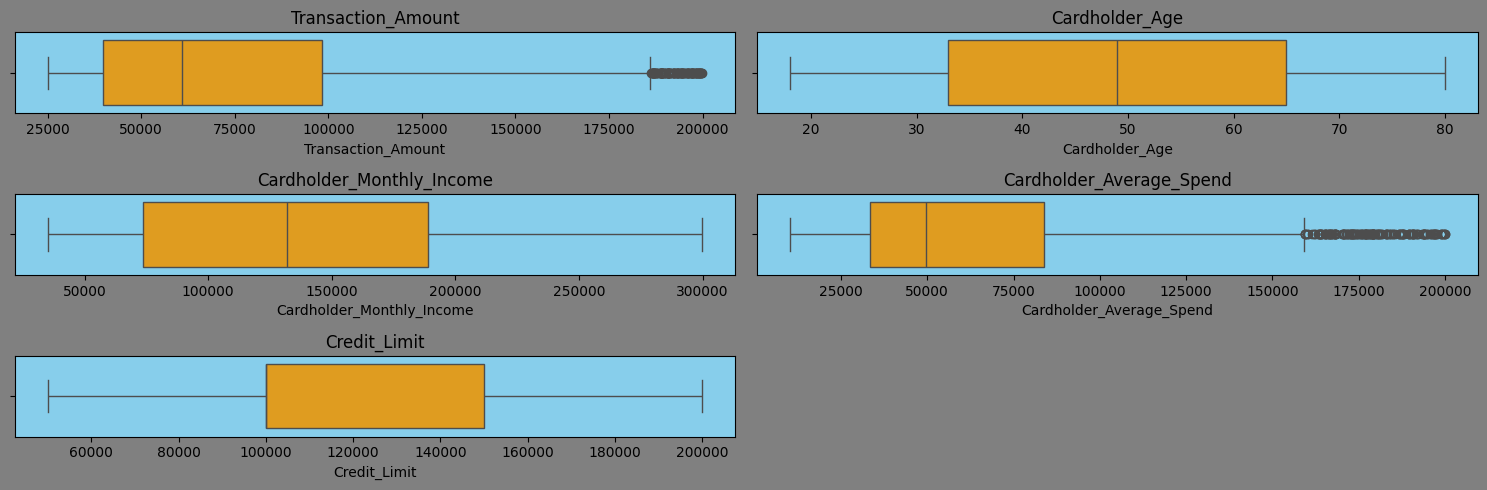

In [ ]:
plt.figure(figsize = (15, 5), facecolor = "gray", edgecolor = "teal")
for i, j in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  fig = sns.boxplot(data = df, x = j, color = "orange")
  fig.set_facecolor("skyblue")
  plt.title(j)
plt.tight_layout()
plt.show()

# 1 Exploratory Data Analysis (EDA):

## a) Analyze the distribution of categorical features such as Card_Type, Merchant_Category.

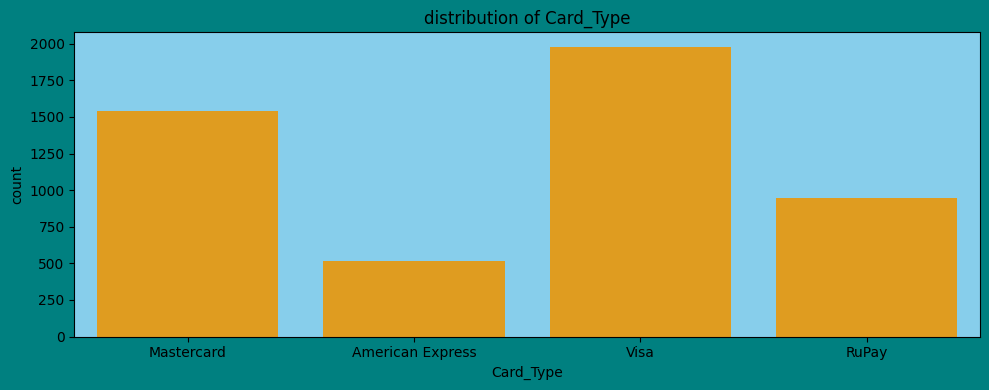

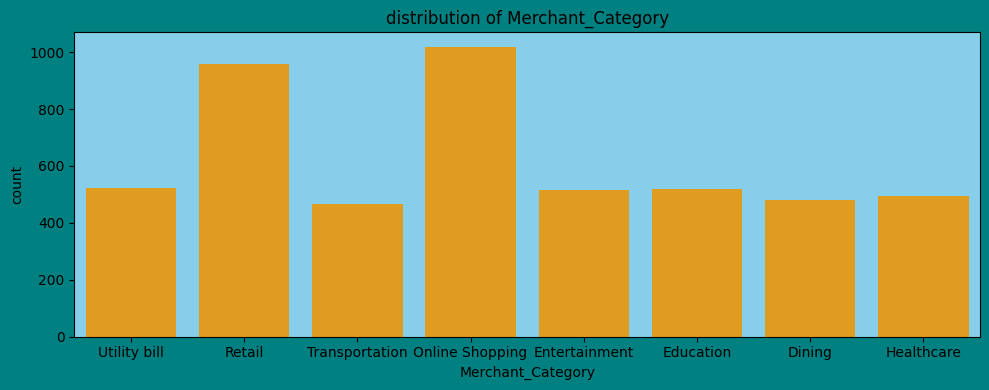

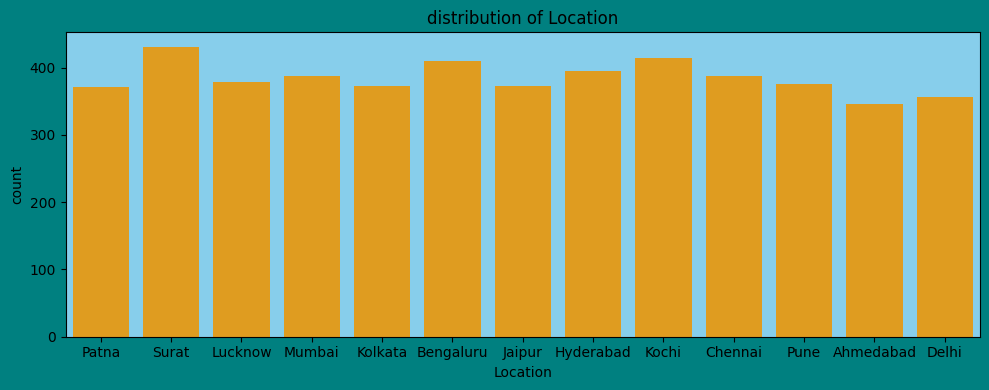

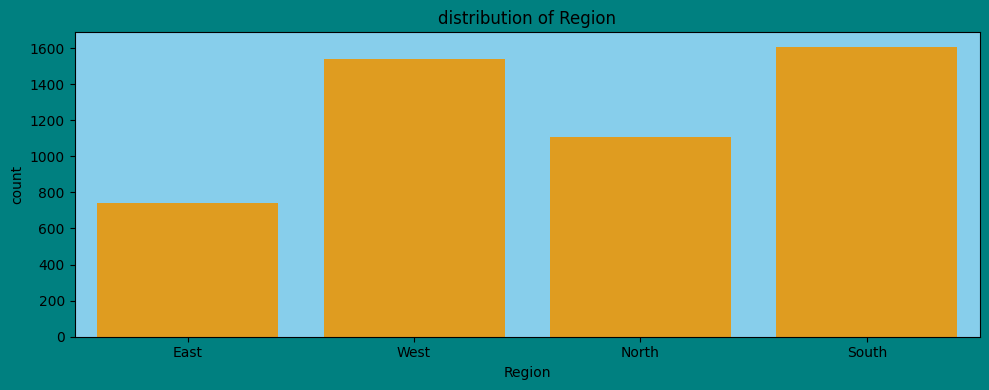

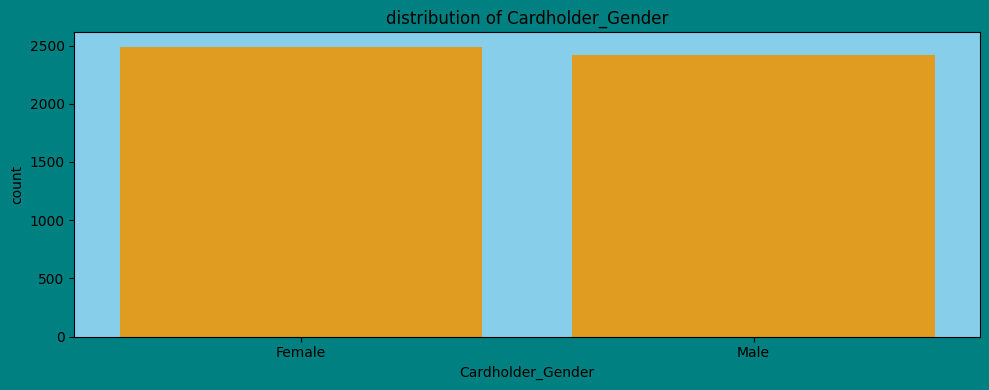

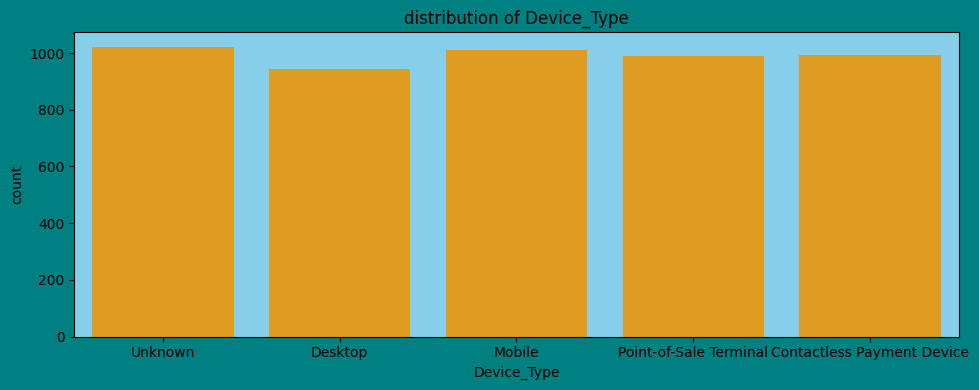

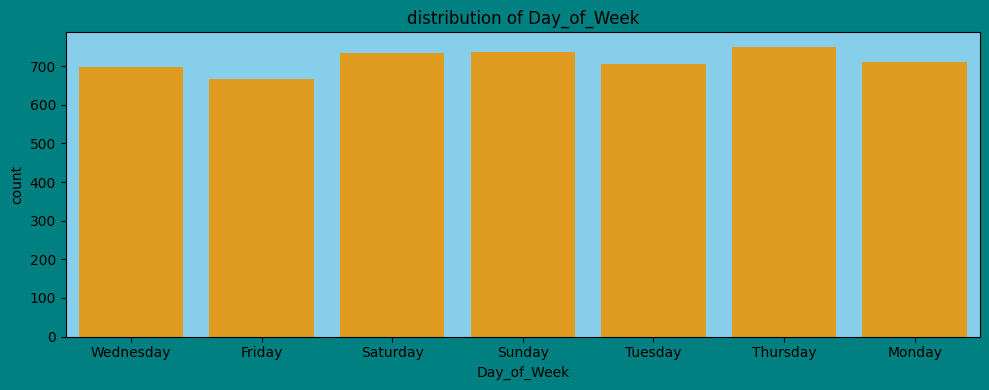

In [ ]:
categorical_features = ['Card_Type','Merchant_Category','Location','Region','Cardholder_Gender','Device_Type','Day_of_Week']
for col in categorical_features:
   plt.figure(figsize=(10, 4), facecolor = "teal")
   fig1 = sns.countplot(x=col,data = df, color = "orange")
   fig1.set_facecolor("skyblue")
   plt.title(f'distribution of {col}')
   plt.tight_layout()
   plt.show()

## b) Explore numerical features

In [ ]:
numerical_features = ['Transaction_Amount','Cardholder_Age','Cardholder_Monthly_Income','Cardholder_Average_Spend']
print(df[numerical_features].describe())

       Transaction_Amount  Cardholder_Age  Cardholder_Monthly_Income  \
count         4994.000000     4865.000000                4686.000000   
mean         74667.995995       49.106680              137353.817542   
std          43089.045623       18.398524               69471.623020   
min          25008.000000       18.000000               35005.000000   
25%          39742.500000       33.000000               73485.000000   
50%          60922.000000       49.000000              131833.000000   
75%          98373.500000       65.000000              189054.250000   
max         199923.000000       80.000000              299907.000000   

       Cardholder_Average_Spend  
count               4792.000000  
mean               63058.343566  
std                40056.989704  
min                10282.410000  
25%                33336.742500  
50%                49547.945000  
75%                83732.352500  
max               199898.290000  


## c) Conduct bivariate and multivariate analysis

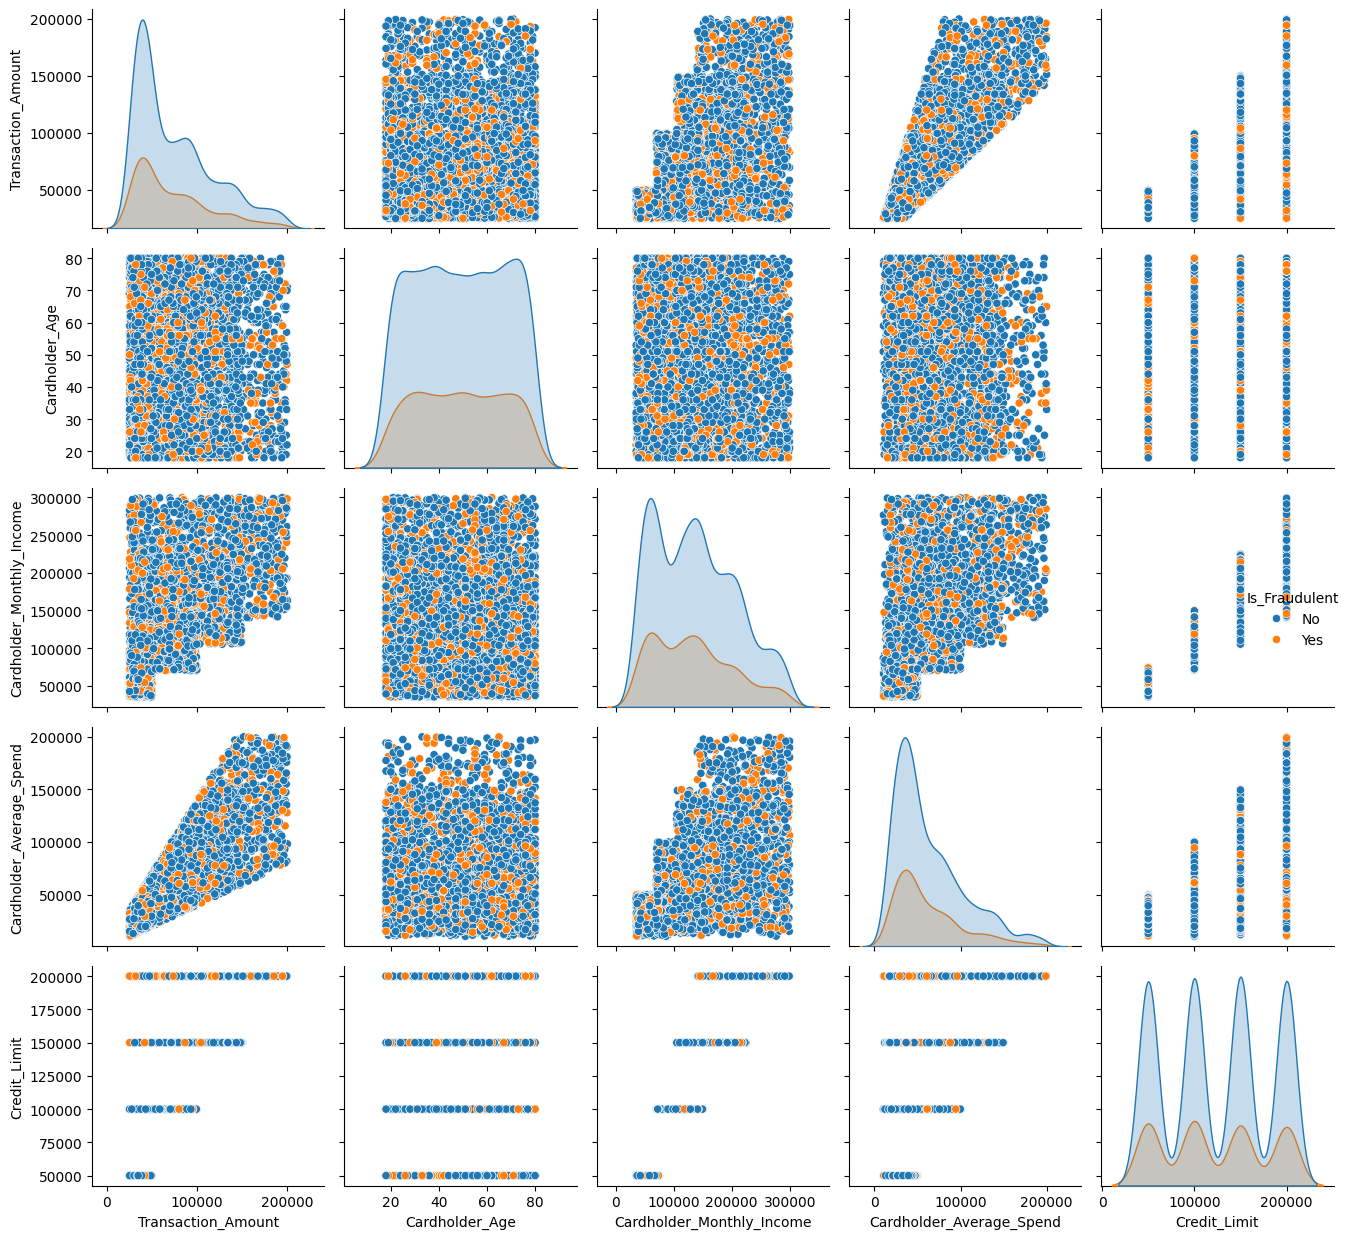

In [ ]:
fig4 = sns.pairplot(df,hue = 'Is_Fraudulent',diag_kind = 'kde')
plt.tight_layout()
plt.show()

## d) Visualize the distribution of transaction amounts for fraudulent vs. non-fraudulenttransactions using histograms or box plots.

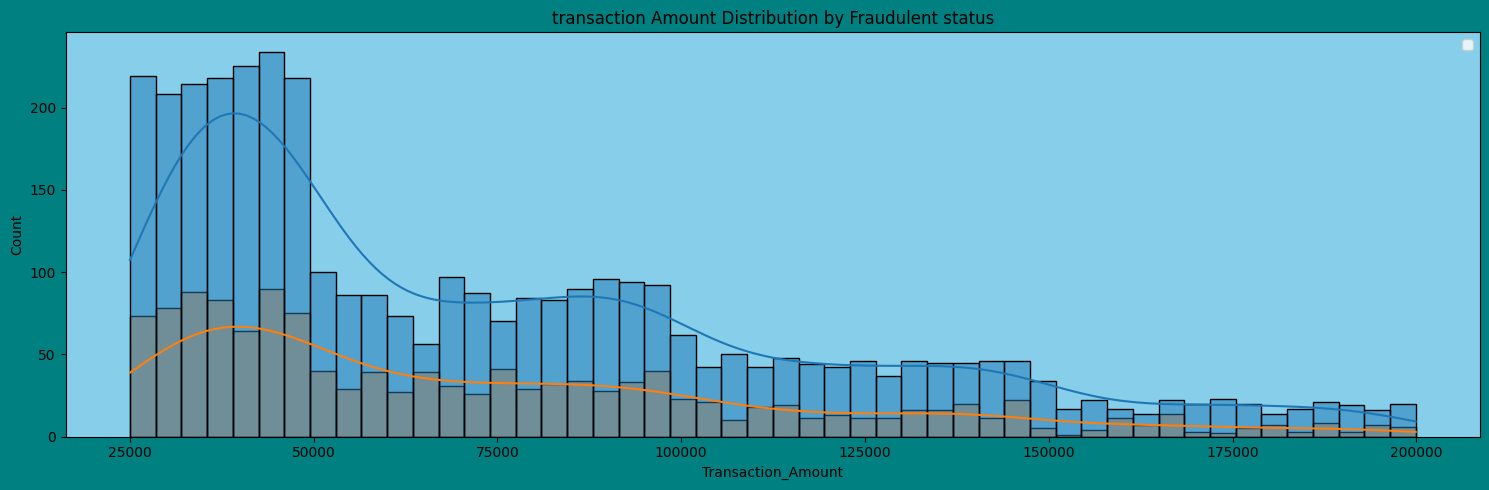

In [ ]:
plt.figure(figsize = (15,5), facecolor = "teal")
fig1 = sns.histplot(data=df,x = 'Transaction_Amount',hue = 'Is_Fraudulent',kde =True ,bins = 50)
fig1.set_facecolor("skyblue")
plt.title('transaction Amount Distribution by Fraudulent status')
plt.legend()
plt.tight_layout()
plt.show()

## e) Investigate whether certain features are more susceptible to fraud.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

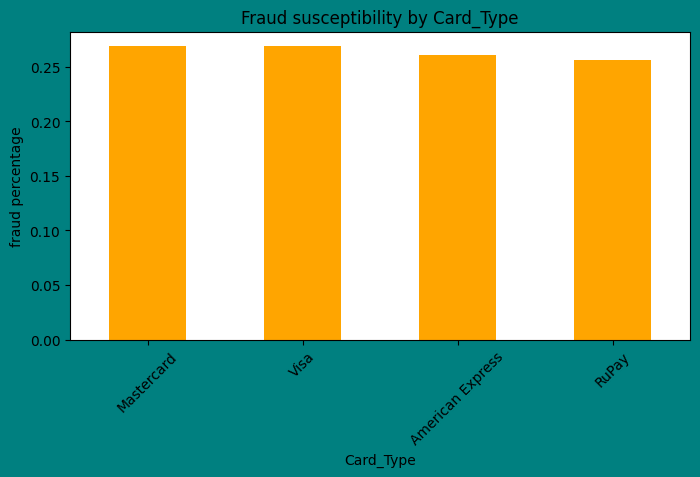

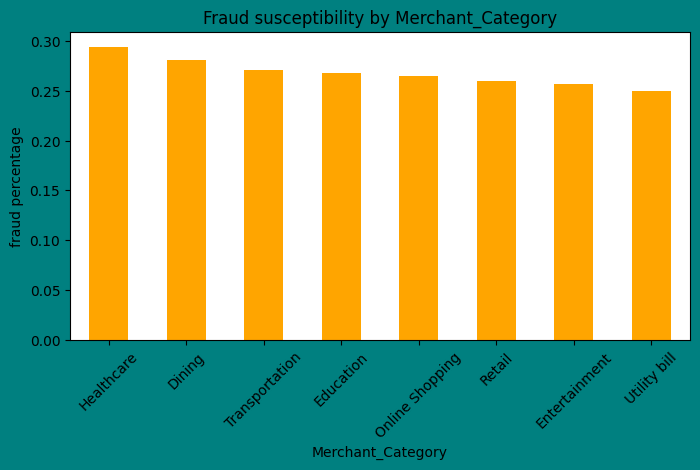

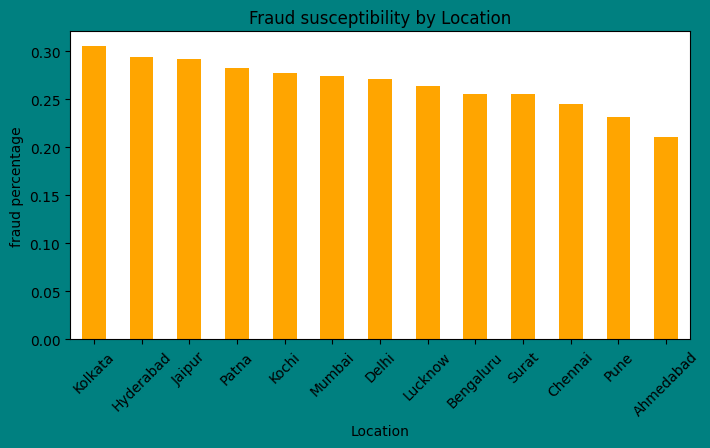

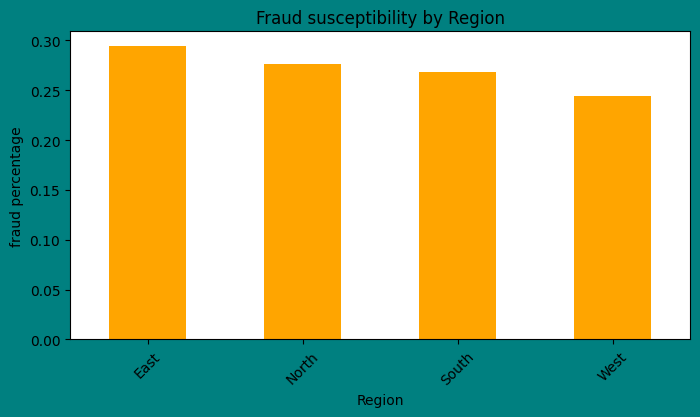

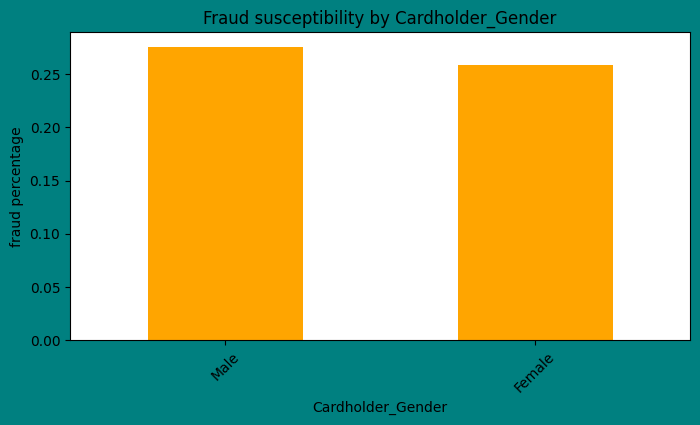

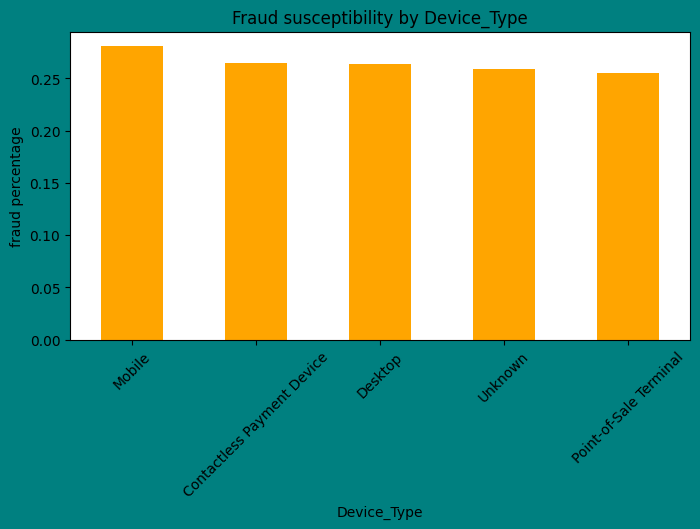

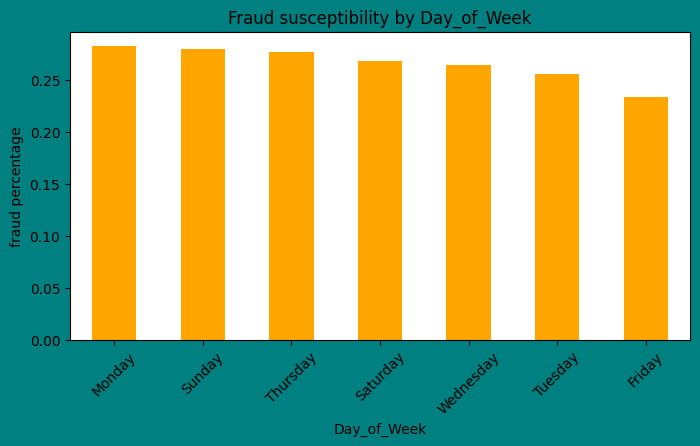

In [ ]:
for col in categorical_features:
  plt.figure(figsize=(8,4), facecolor = "teal")
  df['Is_Fraudulent'] = df['Is_Fraudulent'].replace({'Yes':1,'No':0}).astype(int)
  fraud_percentage = df.groupby(col)['Is_Fraudulent'].mean()
  fraud_percentage.sort_values(ascending = False).plot(kind = 'bar', color = "orange")
  plt.title(f'Fraud susceptibility by {col}')
  plt.xticks(rotation = 45)
  plt.ylabel('fraud percentage')
  plt.show()

# 2) Data Preprocessing - Data Cleaning:

## a) Handle missing values

In [ ]:
imputer = SimpleImputer(strategy = 'most_frequent')
df.fillna(df.mode().iloc[0],inplace=True)
df.isnull().sum()

,0
Transaction_ID,0
Card_Type,0
Merchant_Category,0
Transaction_Amount,0
Transaction_DateTime,0
Location,0
Region,0
Cardholder_Age,0
Cardholder_Gender,0
Cardholder_Monthly_Income,0


## b) detecting and handling the outliers using the IQR

In [ ]:
for col in  numerical_features:
  Q1 = df[col].quantile(0.25)
  Q3 =df[col].quantile(0.75)
  IQR = Q3- Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q1 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

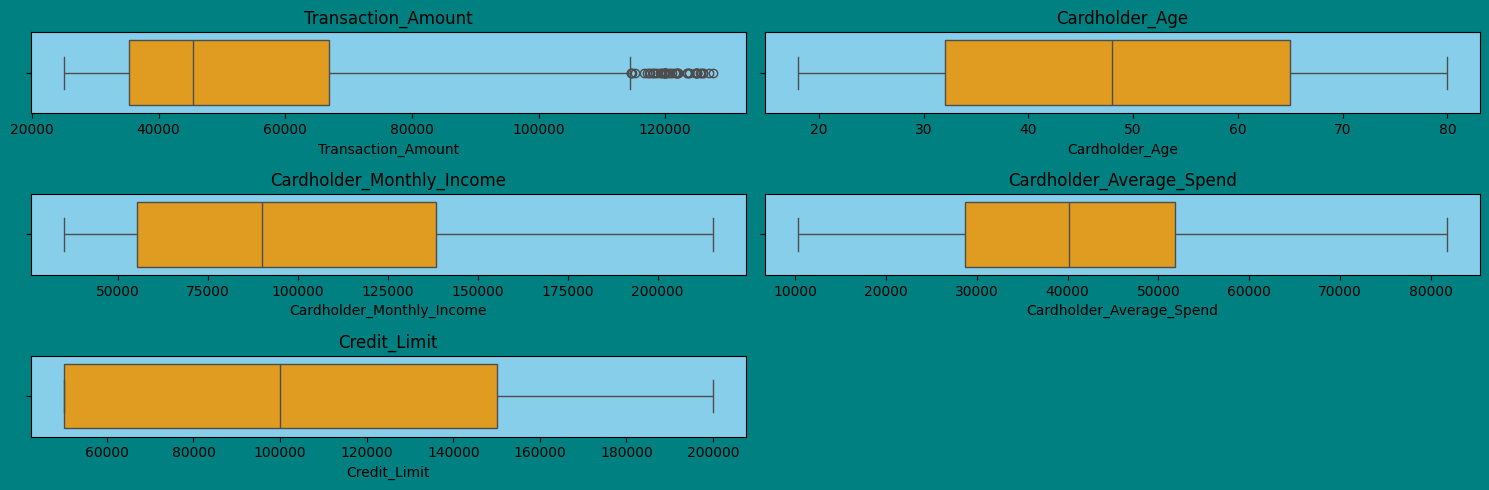

In [ ]:
plt.figure(figsize = (15, 5), facecolor = "teal", edgecolor = "teal")
for i, j in enumerate(num_cols, 1):
  plt.subplot(3, 2, i)
  fig = sns.boxplot(data = df, x = j, color = "orange")
  fig.set_facecolor("skyblue")
  plt.title(j)
plt.tight_layout()
plt.show()

## cheaking the skewness

In [ ]:
for col in numerical_features:
  skewness = df[col].skew()
  if abs(skewness) > 1:
    df[col] = np.log1p(df[col])

# 3) Feature Engineering:

## a) Identify the categorical features in the dataset.

In [ ]:
categorical_features = ['Card_Type','Merchant_Category','Location','Region','Cardholder_Gender','Device_Type','Day_of_Week']

## b) Encoding the  categorical features

In [ ]:
encoder = LabelEncoder()
for col in df[categorical_features]:
  df[col] = encoder.fit_transform(df[col])

In [ ]:
df.head()

,Transaction_ID,Card_Type,Merchant_Category,Transaction_Amount,Transaction_DateTime,Location,Region,Cardholder_Age,Cardholder_Gender,Cardholder_Monthly_Income,Cardholder_Average_Spend,Credit_Limit,Device_Type,Day_of_Week,Is_Fraudulent
0,W963UK57,1,7,10.211524,2020-01-01 09:43:17,10,0,23.0,0,94632.0,36369.65,100000.0,4,6,0
4,K256ZN73,2,5,11.304313,2020-01-04 17:26:47,8,1,37.0,0,174470.0,52713.09,200000.0,2,2,0
7,R809YU99,2,4,10.819138,2020-01-05 19:37:50,12,3,46.0,0,56248.0,45671.98,50000.0,3,3,0
8,Q473IV29,1,2,10.703896,2020-01-05 19:55:48,7,0,44.0,1,93854.0,29653.72,100000.0,4,3,0
9,V841LV15,1,5,10.295124,2020-01-05 23:30:04,10,0,77.0,0,55448.0,22530.16,50000.0,3,3,0


In [ ]:
x = df.drop(["Transaction_ID","Transaction_DateTime","Is_Fraudulent"],axis=1)
y=df["Is_Fraudulent"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = LogisticRegression()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"Logistic Regression : ",accuracy_score(y_test,y_pred) )

Logistic Regression :  0.6933333333333334


In [ ]:
model = GaussianNB()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"Gaussian NB : ",accuracy_score(y_test,y_pred) )

Gaussian NB :  0.6933333333333334


In [ ]:
model = RandomForestClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"Random Forest Classifier : ",accuracy_score(y_test,y_pred))

Random Forest Classifier :  0.6909090909090909


In [ ]:
model = DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"Decision Tree Classifier : ",accuracy_score(y_test,y_pred) )

Decision Tree Classifier :  0.566060606060606


In [ ]:
model = SVC()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"SVC : ",accuracy_score(y_test,y_pred) )

SVC :  0.6933333333333334


In [ ]:
model = KNeighborsClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(f"K Neighbors Classifier : ",accuracy_score(y_test,y_pred))

K Neighbors Classifier :  0.6472727272727272


# Conclusion:
I analysed these 5 models. Comparitively Logistic Regression is quite good. All models are good but its good to compare all these.